# AI Architecture Integrity — Analysis Notebook

Visual exploration for `docs/methodology/analysis.md`'s five-stage analysis
plan. Every section below corresponds 1:1 to a numbered subsection of that
document — read it first for the *why* behind each chart; this notebook is
the *what the data actually shows*.

**Data flow**: `src/ingest.py` parses raw experiment artifacts
(`reports/experiments/**/*.json`, `reports/baseline/*.json`,
`session_manifest.yaml`) into `data/*.csv`. Each `src/stages/s*.py` script
reads those CSVs (never the raw JSON) and writes its derived result to
`data/derived/*.csv`. This notebook only reads `data/` and `data/derived/`
and only draws charts — it recomputes nothing itself.

Run the regeneration cell below whenever `reports/experiments/` has new
runs; otherwise skip straight to Stage 0.

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

ANALYSIS_DIR = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
sys.path.insert(0, str(ANALYSIS_DIR / "src"))

from paths import DATA_DIR, DERIVED_DIR  # noqa: E402
import charts  # noqa: E402

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

## Regenerate `data/` and `data/derived/` (optional)

Set `REGENERATE = True` and run this cell after new experiment sessions
land under `reports/experiments/`. Each stage script is independently
runnable from the command line too (`python3 src/stages/s1_1_violation_
heatmap.py`) — this cell just calls them in the dependency order s2_2 and
s4_1 need (both read another stage's `data/derived/*.csv` output; see their
docstrings).

In [2]:
REGENERATE = False

if REGENERATE:
    import subprocess

    ordered_scripts = [
        "ingest.py",
        "stages/s0_1_reliability.py",
        "stages/s0_2_baseline_debt.py",
        "stages/s0_3_task_completion.py",
        "stages/s1_1_violation_heatmap.py",
        "stages/s1_2_metric_distribution.py",
        "stages/s2_1_strategy_comparison.py",
        "stages/s2_2_agent_profile.py",
        "stages/s3_1_trajectory_shape.py",
        "stages/s4_1_silent_decay.py",
        "stages/s4_2_spatial_distribution.py",
        "stages/s4_3_metric_correlation.py",
    ]
    for script in ordered_scripts:
        result = subprocess.run([sys.executable, str(ANALYSIS_DIR / "src" / script)], capture_output=True, text=True)
        print(f"== {script} (exit {result.returncode}) ==")
        print(result.stdout)
        if result.returncode != 0:
            print(result.stderr)
            break

---
## Stage 0 — Data Quality & Baseline Calibration

Before reading any result below: is this batch of data trustworthy?

### §2.1 Harness reliability

Which metrics come back `status: "error"` most often, and which runs have a
scope-level failure? Both are tool problems, not architecture findings —
they should be excluded from (or footnoted in) every later chart.

,evaluation_id,session_id,task_id,agent,strategy,execution_status,comparison_status,backend_status,frontend_status,cross_status,scope_errors,metric_errors,metric_coverage,is_reliable
0,session_20260817_031026/T3,session_20260817_031026,T3,codex,structured,partial,valid,error,completed,completed,1,1,0.95,False


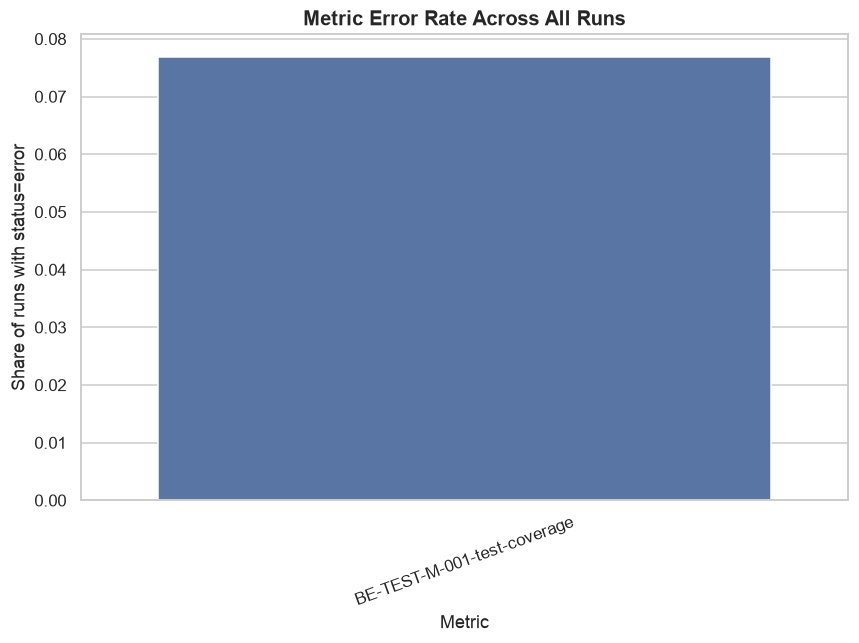

In [3]:
error_rates = pd.read_csv(DERIVED_DIR / "metric_error_rates.csv")
reliability = pd.read_csv(DERIVED_DIR / "run_reliability.csv")

flaky = error_rates[error_rates["error_rate"] > 0].sort_values("error_rate", ascending=False)
if not flaky.empty:
    charts.grouped_bar(
        flaky,
        x="metric_name",
        y="error_rate",
        title="Metric Error Rate Across All Runs",
        xlabel="Metric",
        ylabel="Share of runs with status=error",
    )
else:
    print("No metric ever returned status=error in this dataset.")

display(reliability.loc[~reliability["is_reliable"]])

### §2.2 Pre-existing debt subtraction (net-new violations)

Baseline's own violations must not be credited to the agent. The
baseline-vs-baseline self-check should always read `True` — it validates
that the delta pipeline itself has no bug.

In [4]:
import json

debt_table = pd.read_csv(DERIVED_DIR / "baseline_debt_by_category.csv")
self_check = json.loads((DERIVED_DIR / "baseline_self_check.json").read_text())

print(f"Baseline self-check passes: {self_check['passes_self_check']}")
display(debt_table)

Baseline self-check passes: True


,category,baseline_absolute_count,avg_agent_absolute_count,avg_trajectory_net_new
0,ERR,0.0,12.800000,12.800000
1,CONTRACT,0.0,6.000000,6.000000
2,DUP,3.0,8.166667,5.833333
3,DEP,0.0,2.000000,2.000000
4,COM,0.0,1.571429,1.571429
5,DOM,0.0,1.500000,1.500000
6,SIZE,0.0,1.000000,1.000000
7,STATE,2.0,2.000000,0.000000


### §2.3 Task completion gate

`harness_evaluation.json` says nothing about whether the agent finished
cleanly or whether the feature it built passed acceptance tests. `fail` is
a real functional gap (not an architecture data problem); `error` means the
acceptance *infrastructure* didn't run and should be treated like a tool
failure, same as §2.1.

Every agent run in this dataset finished per protocol.


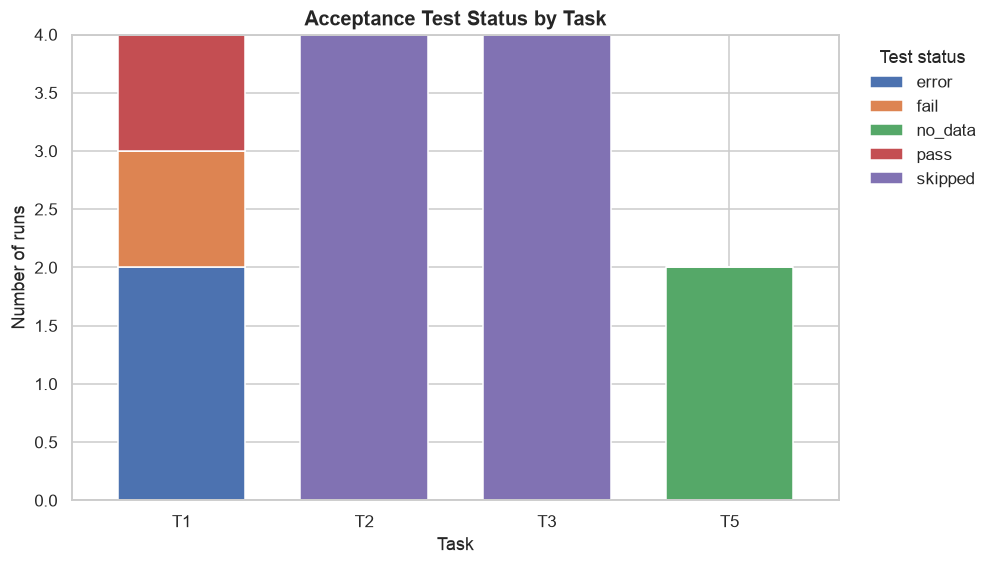

In [5]:
completion = pd.read_csv(DERIVED_DIR / "task_completion_gate.csv")

status_by_task = (
    completion.groupby(["task_id", "test_status"]).size().unstack(fill_value=0)
)
charts.stacked_bar(
    status_by_task,
    title="Acceptance Test Status by Task",
    xlabel="Task",
    ylabel="Number of runs",
    legend_title="Test status",
)

flagged = completion.loc[completion["flagged_for_review"]]
if not flagged.empty:
    print("Runs flagged for review (agent did not finish cleanly):")
    display(flagged)
else:
    print("Every agent run in this dataset finished per protocol.")

---
## Stage 1 — Descriptive Overview

No condition splits yet — where do violations concentrate overall?

### §3.1 Violation heatmap (agent × category)

Net-new (`run_local`) violations per run, averaged within each agent, one
column per rule category.

<Axes: title={'center': 'Mean Net-New Violations per Run by Agent and Category'}, xlabel='Rule category', ylabel='Agent'>

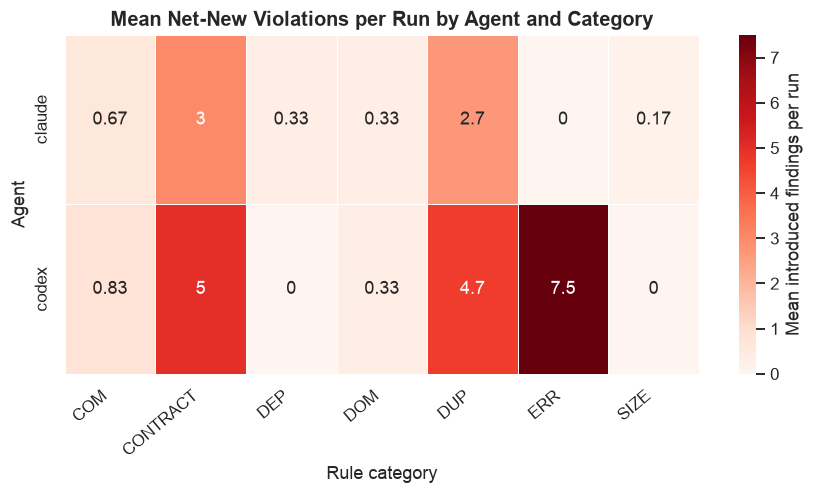

In [6]:
violation_matrix = pd.read_csv(DERIVED_DIR / "violation_rate_matrix.csv", index_col=0)
charts.heatmap(
    violation_matrix.values,
    row_labels=list(violation_matrix.index),
    col_labels=list(violation_matrix.columns),
    title="Mean Net-New Violations per Run by Agent and Category",
    cbar_label="Mean introduced findings per run",
    xlabel="Rule category",
    ylabel="Agent",
)

### §3.2 Metric distribution overview

Bounded metrics (ratio/percent, roughly 0–1) and unbounded metrics (counts,
levels, params, props) are plotted separately since they don't share a
scale.

<Axes: title={'center': 'Unbounded Metric Distributions (count / levels / params / props)'}, xlabel='Metric', ylabel='Value'>

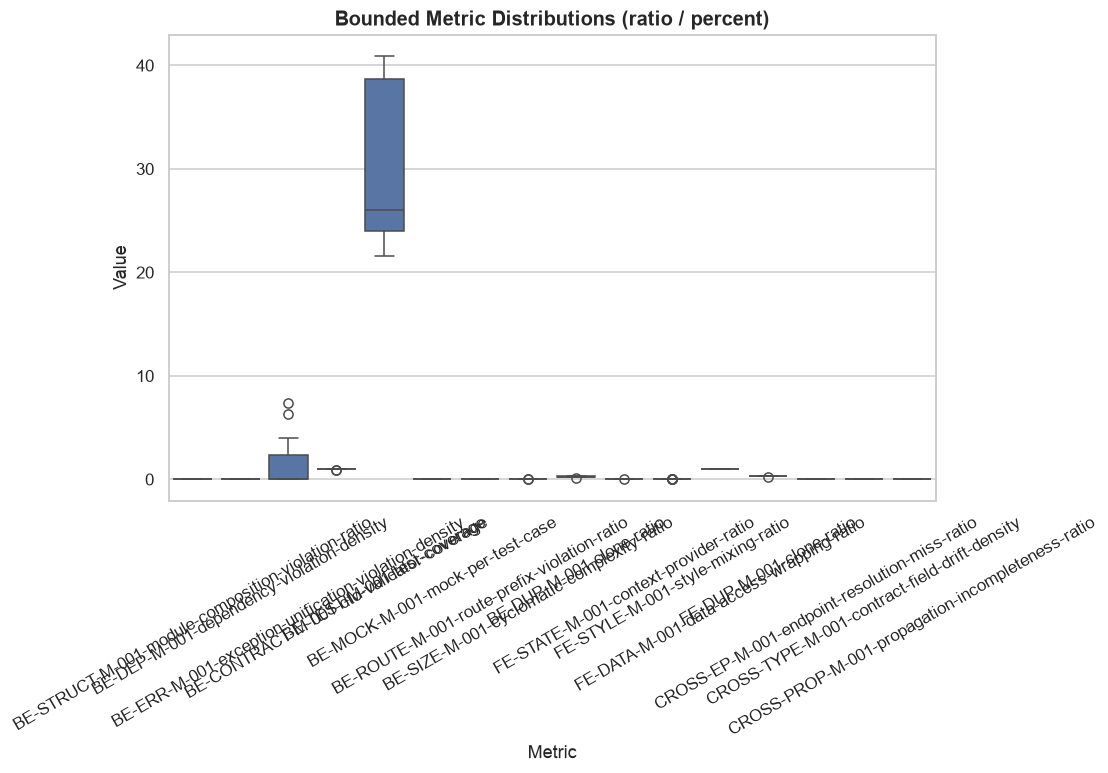

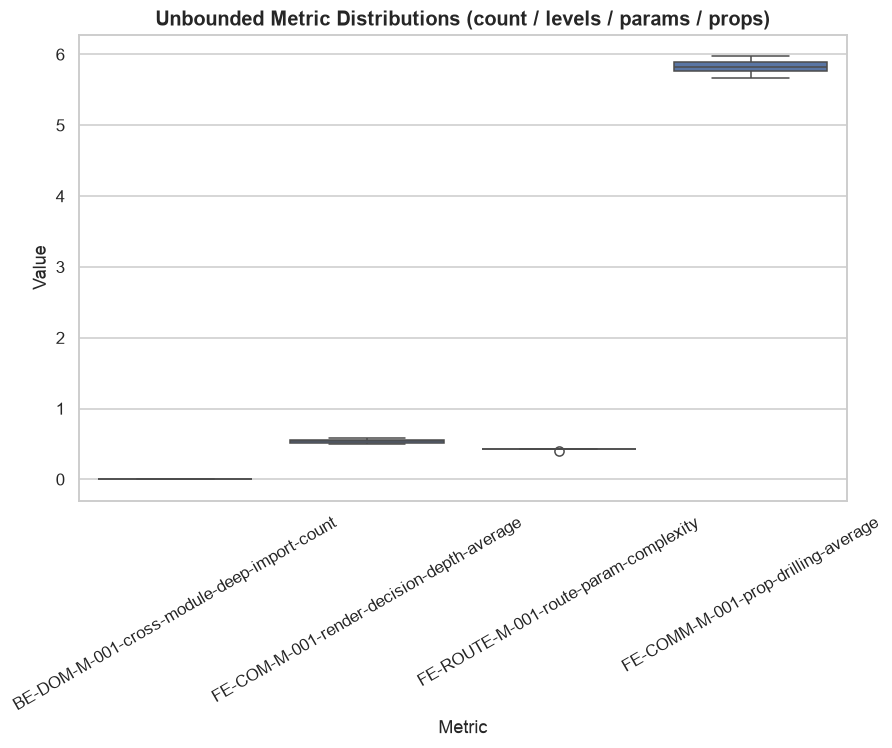

In [7]:
metric_observations = pd.read_csv(DATA_DIR / "metric_observations.csv").dropna(subset=["value"])
bounded_units = {"ratio", "percent"}
bounded = metric_observations[metric_observations["unit"].isin(bounded_units)]
unbounded = metric_observations[~metric_observations["unit"].isin(bounded_units)]

charts.box_or_violin(
    bounded, x="metric_name", y="value",
    title="Bounded Metric Distributions (ratio / percent)",
    xlabel="Metric", ylabel="Value",
)
charts.box_or_violin(
    unbounded, x="metric_name", y="value",
    title="Unbounded Metric Distributions (count / levels / params / props)",
    xlabel="Metric", ylabel="Value",
)

---
## Stage 2 — Cross-Condition Comparison

### §4.1 Prompt strategy comparison (minimal vs structured)

Paired per `(agent, task)`. A downward-sloping line means `structured`
introduced fewer net-new violations than `minimal` for that pair.

{
  "claude": {
    "n_pairs": 3,
    "statistic": 2.5,
    "p_value": 1.0,
    "median_diff": -1.0,
    "note": null
  },
  "codex": {
    "n_pairs": 3,
    "statistic": 0.0,
    "p_value": 0.25,
    "median_diff": 5.0,
    "note": null
  },
  "overall": {
    "n_pairs": 6,
    "statistic": 3.5,
    "p_value": 0.1875,
    "median_diff": 2.5,
    "note": null
  }
}


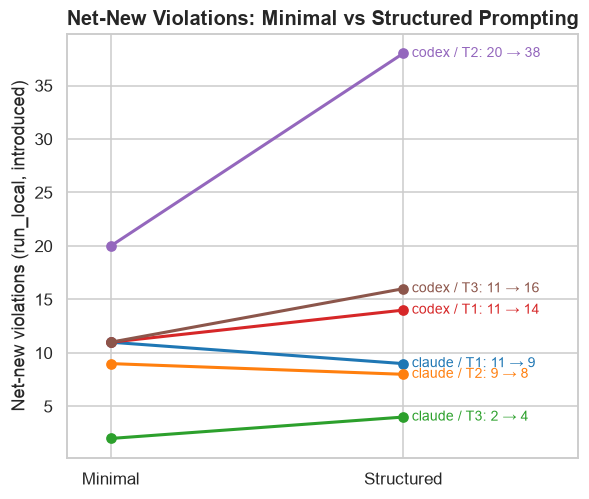

In [8]:
pairs = pd.read_csv(DERIVED_DIR / "strategy_comparison_pairs.csv")
strategy_tests = json.loads((DERIVED_DIR / "strategy_comparison_test.json").read_text())

if {"minimal", "structured"}.issubset(pairs.columns) and not pairs.empty:
    pairs["label"] = pairs["agent"] + " / " + pairs["task_id"]
    charts.slope_chart(
        pairs, left_col="minimal", right_col="structured", label_col="label",
        title="Net-New Violations: Minimal vs Structured Prompting",
        left_label="Minimal", right_label="Structured",
        ylabel="Net-new violations (run_local, introduced)",
    )
else:
    print("Not enough paired (minimal, structured) runs yet.")

print(json.dumps(strategy_tests, indent=2))

### §4.2 Agent "architecture personality"

Same matrix as §3.1, one polygon per agent — compare *shape*, not just
overall size.

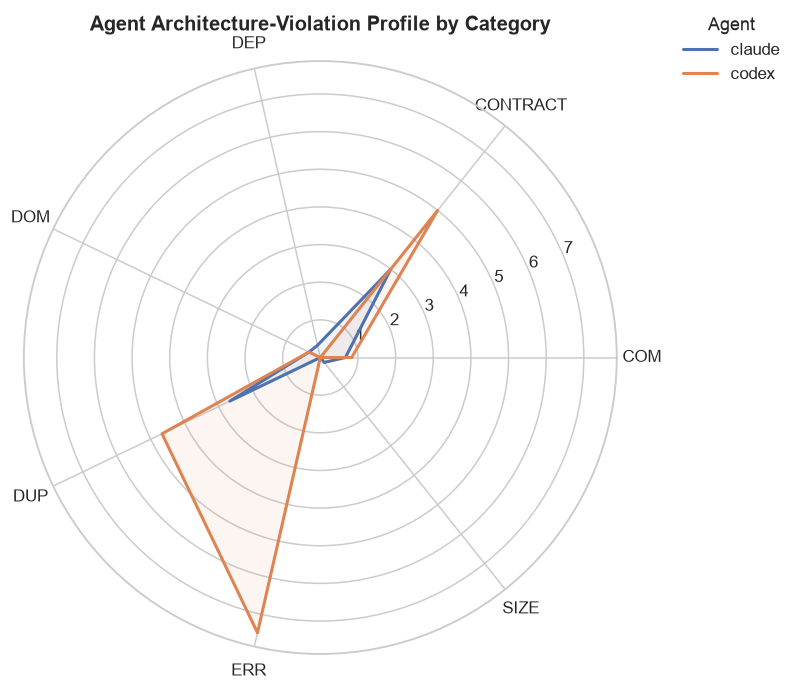

In [9]:
profile_matrix = pd.read_csv(DERIVED_DIR / "agent_profile_matrix.csv", index_col=0)
if len(profile_matrix) >= 1:
    charts.radar(
        categories=list(profile_matrix.columns),
        series={agent: row.tolist() for agent, row in profile_matrix.iterrows()},
        title="Agent Architecture-Violation Profile by Category",
        legend_title="Agent",
    )

---
## Stage 3 — Longitudinal Trend

### §5.1 Trajectory curve shape

`trajectory_cumulative` net-new violations, relative to the *original*
baseline, across the task sequence for each `agent × strategy` condition.

,agent,strategy,n_points,final_trajectory_introduced_count,shape
0,claude,minimal,3,9,plateau_or_decline
1,claude,structured,3,9,plateau_or_decline
2,codex,minimal,3,22,plateau_or_decline
3,codex,structured,3,34,plateau_or_decline


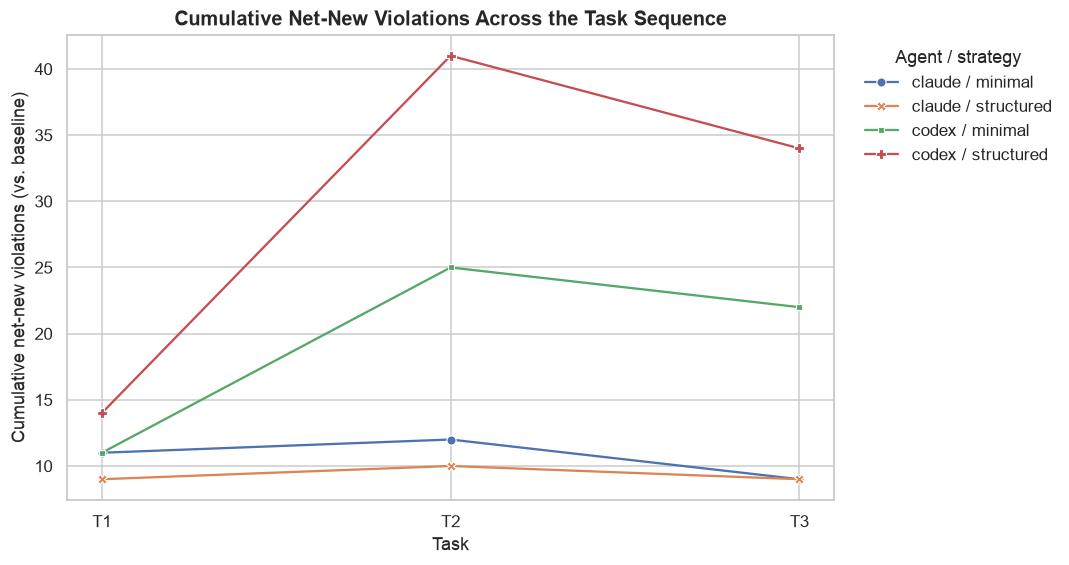

In [10]:
totals = pd.read_csv(DERIVED_DIR / "trajectory_totals.csv")
shapes = pd.read_csv(DERIVED_DIR / "trajectory_shapes.csv")

totals["condition"] = totals["agent"] + " / " + totals["strategy"]
charts.line_trajectory(
    totals, x="task_id", y="trajectory_introduced_count", hue="condition",
    title="Cumulative Net-New Violations Across the Task Sequence",
    xlabel="Task", ylabel="Cumulative net-new violations (vs. baseline)",
    legend_title="Agent / strategy",
)
display(shapes)

---
## Stage 4 — Deep Mechanism Mining

### §6.1 Silent decay

Runs where binary constraints all pass but at least one continuous metric
is already a "bad" outlier by §3.2's IQR fence — the case that motivates
having a `metrics` layer at all, not just `constraints`.

No silent-decay runs in this dataset yet (see note in s4_1's docstring: with this few runs, constraints already fail on almost every run, so there's no 'looks clean' case left for decay to hide behind).


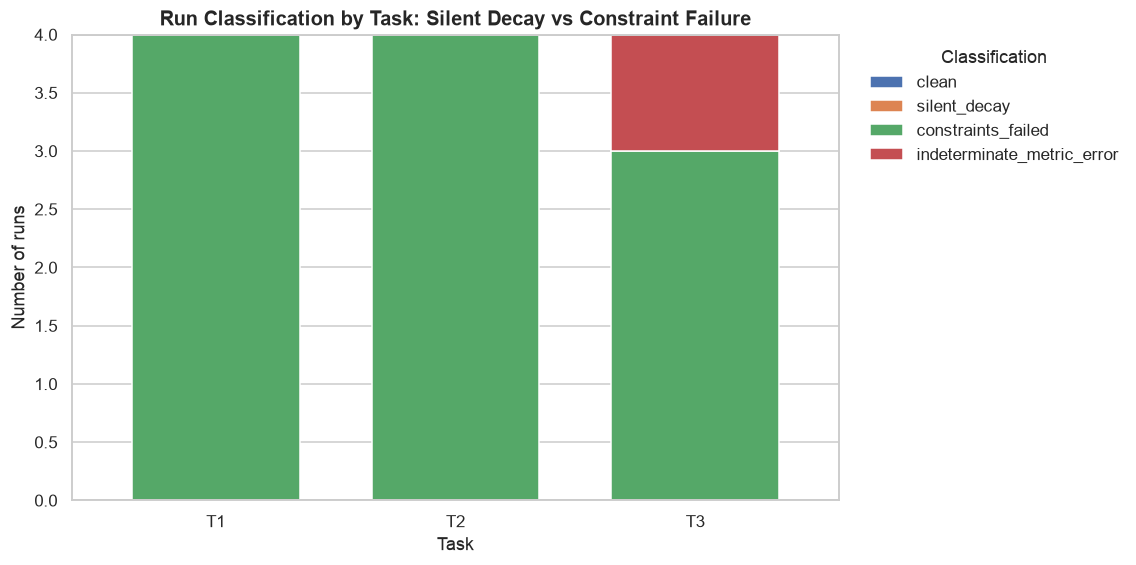

In [11]:
decay = pd.read_csv(DERIVED_DIR / "silent_decay_classification.csv")
order = ["clean", "silent_decay", "constraints_failed", "indeterminate_metric_error"]

by_task = (
    decay.groupby(["task_id", "classification"]).size().unstack(fill_value=0)
    .reindex(columns=order, fill_value=0)
)
charts.stacked_bar(
    by_task,
    title="Run Classification by Task: Silent Decay vs Constraint Failure",
    xlabel="Task", ylabel="Number of runs",
    legend_title="Classification",
)

silent = decay[decay["classification"] == "silent_decay"]
if not silent.empty:
    display(silent[["evaluation_id", "bad_outlier_metrics"]])
else:
    print("No silent-decay runs in this dataset yet (see note in s4_1's docstring: "
          "with this few runs, constraints already fail on almost every run, so there's "
          "no 'looks clean' case left for decay to hide behind).")

### §6.2 Violation spatial distribution (concentrated vs diffuse)

Gini coefficient of net-new findings across touched files, one bar per run
(higher = more concentrated in a handful of files), plus a Lorenz curve for
the single most concentrated run as a worked example.

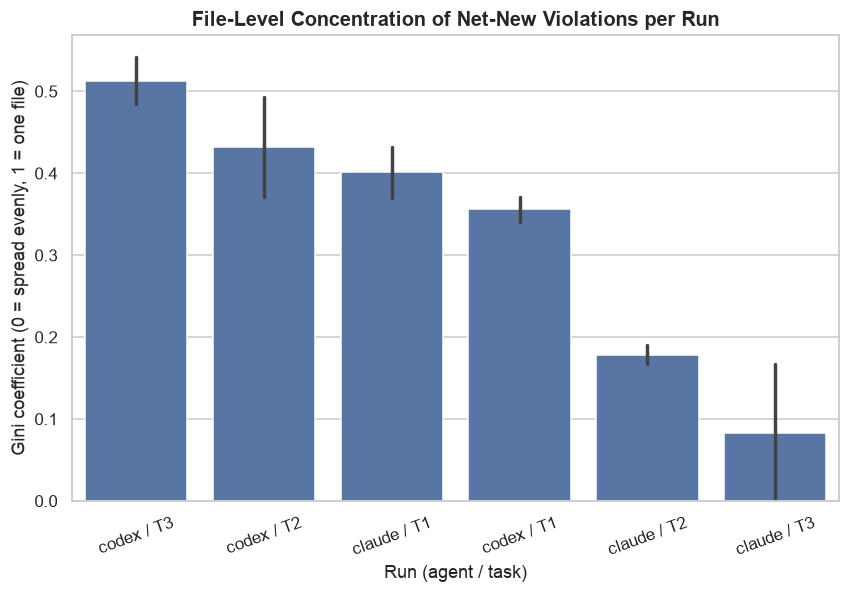

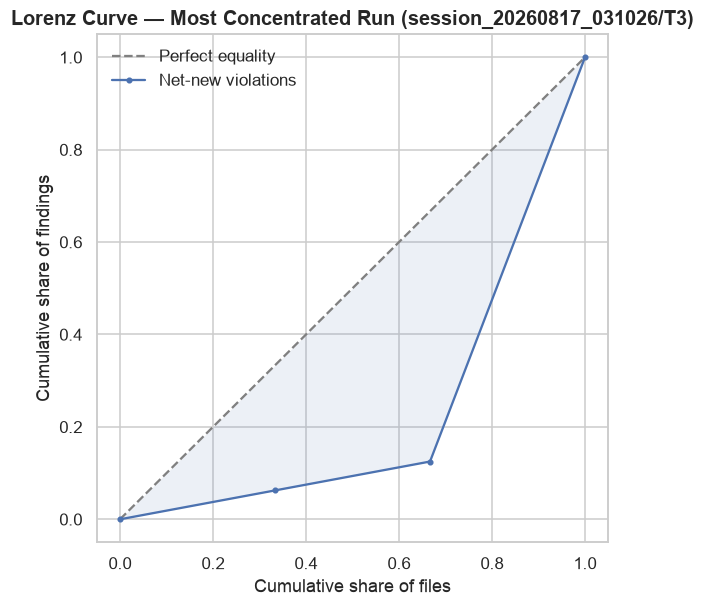

In [12]:
concentration = pd.read_csv(DERIVED_DIR / "file_concentration.csv")
concentration["label"] = concentration["agent"] + " / " + concentration["task_id"]
charts.grouped_bar(
    concentration.sort_values("gini_coefficient", ascending=False),
    x="label", y="gini_coefficient",
    title="File-Level Concentration of Net-New Violations per Run",
    xlabel="Run (agent / task)", ylabel="Gini coefficient (0 = spread evenly, 1 = one file)",
)

if not concentration.empty:
    most_concentrated = concentration.sort_values("gini_coefficient", ascending=False).iloc[0]
    constraint_findings = pd.read_csv(DATA_DIR / "constraint_findings.csv")
    example = constraint_findings[
        (constraint_findings["evaluation_id"] == most_concentrated["evaluation_id"])
        & (constraint_findings["delta_scope"] == "run_local")
        & (constraint_findings["change_type"] == "introduced")
    ]
    file_counts = example.groupby("file").size()
    charts.lorenz_curve(
        file_counts.values,
        title=f"Lorenz Curve — Most Concentrated Run ({most_concentrated['evaluation_id']})",
        series_label="Net-new violations",
    )

### §6.3 Metric correlation structure

Are the ~19 continuous metrics independent signals, or do several measure
the same underlying thing? PCA is attempted with complete-case runs only —
skipped in the printed log if there aren't enough of them yet.

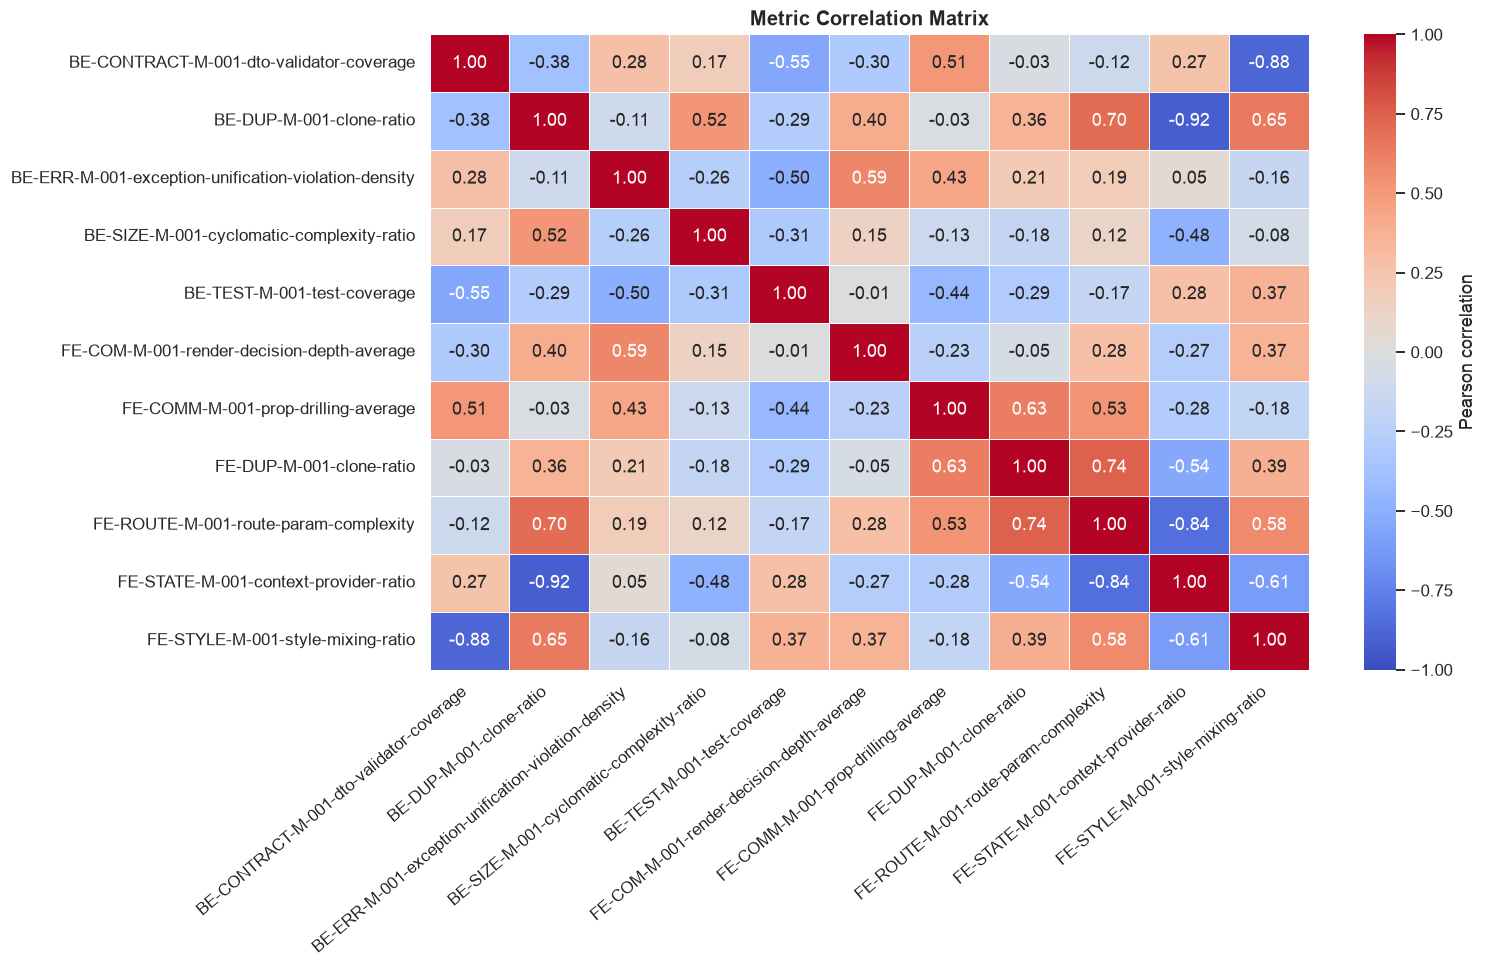

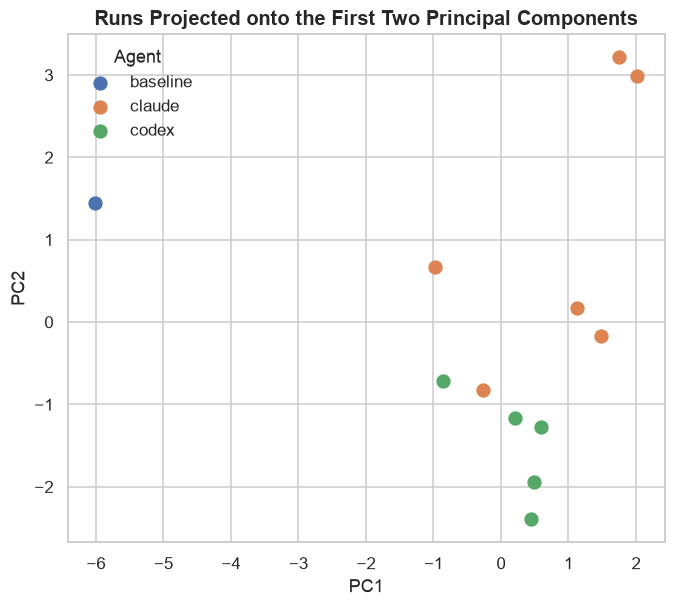

In [13]:
correlation = pd.read_csv(DERIVED_DIR / "metric_correlation.csv", index_col=0)
charts.corr_heatmap(correlation, title="Metric Correlation Matrix")

pca_scores_path = DERIVED_DIR / "metric_pca_scores.csv"
if pca_scores_path.exists():
    pca_scores = pd.read_csv(pca_scores_path, index_col=0)
    pca_scores = pca_scores.join(
        pd.read_csv(DATA_DIR / "runs.csv").set_index("evaluation_id")[["agent", "strategy"]]
    )
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(7, 6))
    for agent, group in pca_scores.groupby("agent"):
        ax.scatter(group["PC1"], group["PC2"], label=agent, s=70)
    ax.set_title("Runs Projected onto the First Two Principal Components")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(title="Agent", frameon=False)
else:
    print("PCA not available yet — see s4_3_metric_correlation.py's printed log for why.")

### §6.4 Agent self-assessment calibration

T5 asks the agent to review its own T1-T3 workspace without seeing the
Harness's objective findings. Does its self-report actually match what the
Harness found at the same commit?

,session_id,agent,strategy,review_status,n_findings,harness_findings_at_t3,blind_spot,under_reported
0,session_20260817_014141,codex,minimal,issues_found,5,26,False,True
1,session_20260817_031026,codex,structured,issues_found,5,38,False,True


,session_id,n_self_reported_findings,n_harness_files_at_t3,n_matched_to_harness_file,match_ratio
0,session_20260817_014141,5,9,2,0.4
1,session_20260817_031026,5,11,5,1.0


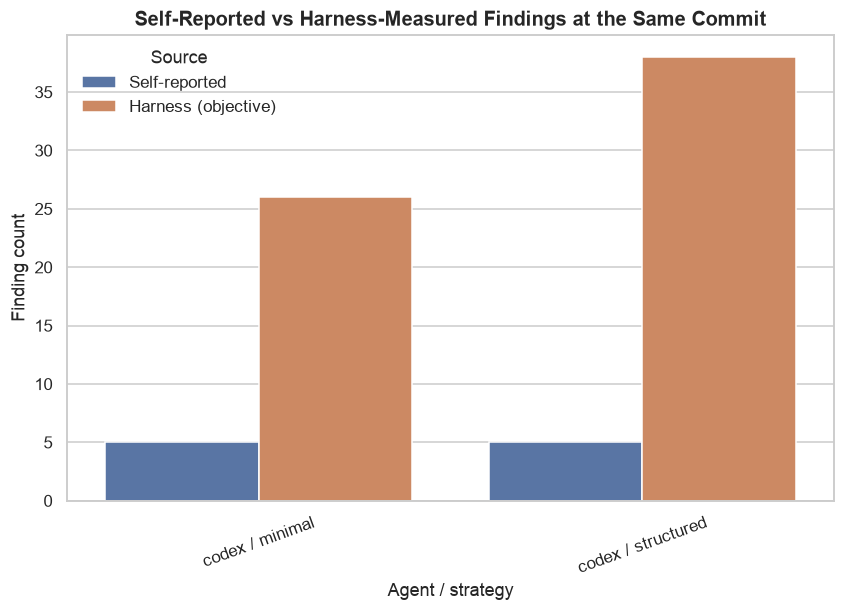

In [14]:
review_runs_path = DATA_DIR / "review_runs.csv"
review_runs = pd.read_csv(review_runs_path) if review_runs_path.exists() else pd.DataFrame()

if review_runs.empty:
    print("No T5 reviews in this dataset yet.")
else:
    ground_truth = pd.read_csv(DERIVED_DIR / "review_ground_truth.csv")
    overlap = pd.read_csv(DERIVED_DIR / "review_location_overlap.csv")

    display(ground_truth[[
        "session_id", "agent", "strategy", "review_status", "n_findings",
        "harness_findings_at_t3", "blind_spot", "under_reported",
    ]])

    comparison = ground_truth.rename(
        columns={"n_findings": "Self-reported", "harness_findings_at_t3": "Harness (objective)"}
    )
    comparison["condition"] = comparison["agent"] + " / " + comparison["strategy"]
    comparison_long = comparison.melt(
        id_vars="condition", value_vars=["Self-reported", "Harness (objective)"],
        var_name="source", value_name="finding_count",
    )
    charts.grouped_bar(
        comparison_long, x="condition", y="finding_count", hue="source",
        title="Self-Reported vs Harness-Measured Findings at the Same Commit",
        xlabel="Agent / strategy", ylabel="Finding count",
        legend_title="Source",
    )

    display(overlap)

---
## Appendix — Agent Execution Cost

Not an architecture-integrity result: how expensive/slow each agent run
was. Useful for the experimental-setup / cost section of the paper, not
Results.

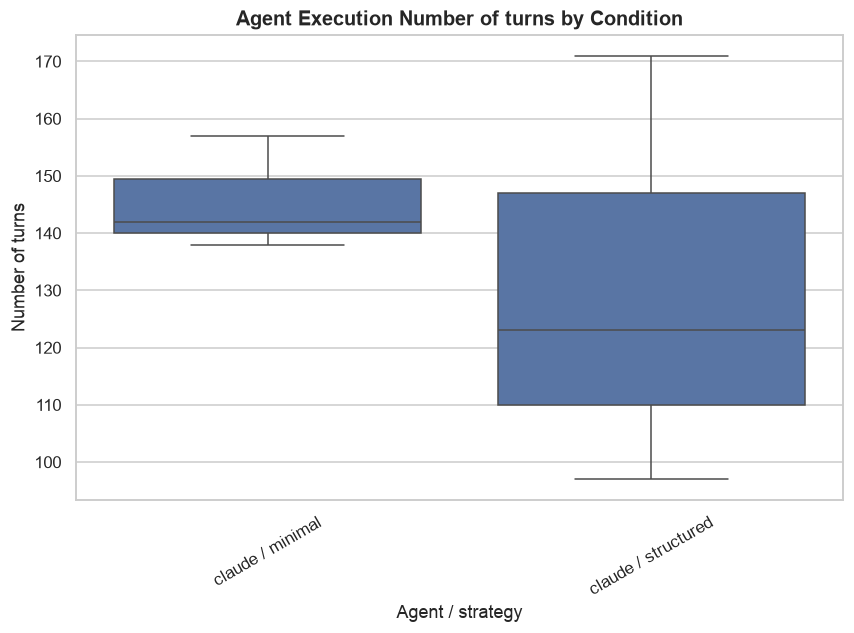

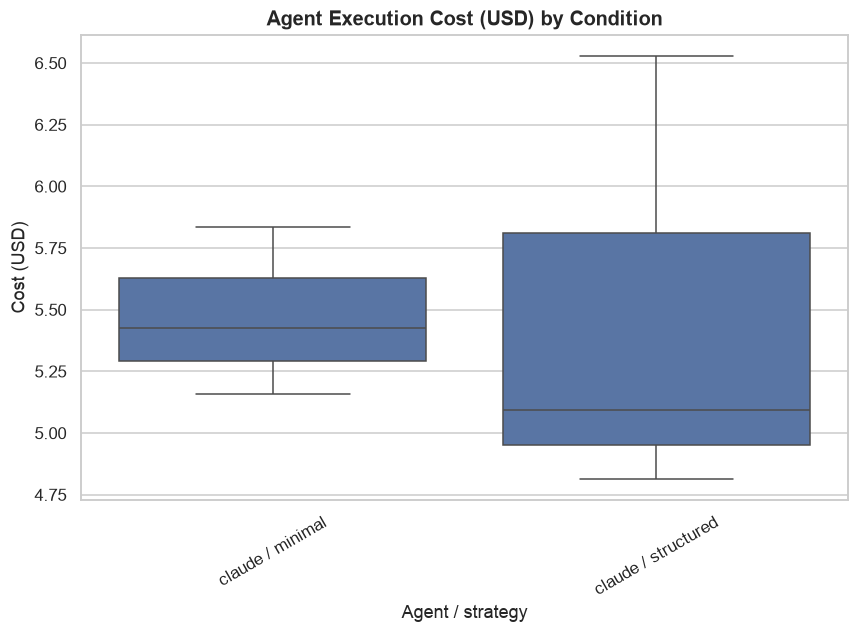

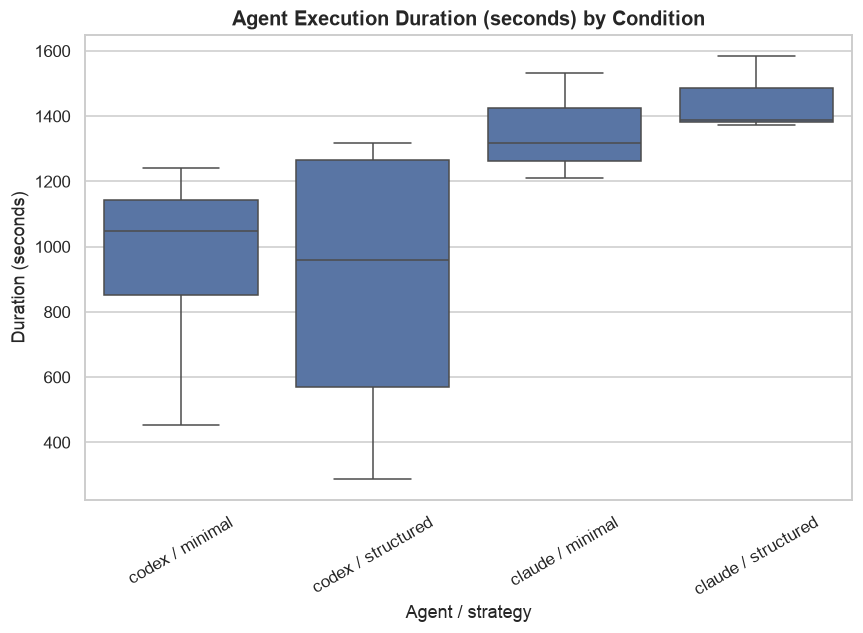

In [15]:
task_completion = pd.read_csv(DATA_DIR / "task_completion.csv")
task_completion["condition"] = task_completion["agent"] + " / " + task_completion["strategy"]

for column, label in [
    ("num_turns", "Number of turns"),
    ("total_cost_usd", "Cost (USD)"),
    ("duration_seconds", "Duration (seconds)"),
]:
    data = task_completion.dropna(subset=[column])
    if data.empty:
        continue
    charts.box_or_violin(
        data, x="condition", y=column,
        title=f"Agent Execution {label} by Condition",
        xlabel="Agent / strategy", ylabel=label,
    )